In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

plt.style.use("ggplot")

In [2]:
path = r"C:\Users\yradh\OneDrive\Desktop\e-commerce_project2\Data\raw"

In [3]:
reviews = pd.read_csv(f"{path}\\olist_order_reviews_dataset.csv")
customers = pd.read_csv(f"{path}\\olist_customers_dataset.csv")
orders = pd.read_csv(f"{path}\\olist_orders_dataset.csv")
order_items = pd.read_csv(f"{path}\\olist_order_items_dataset.csv")
payments = pd.read_csv(f"{path}\\olist_order_payments_dataset.csv")
products = pd.read_csv(f"{path}\\olist_products_dataset.csv")
sellers = pd.read_csv(f"{path}\\olist_sellers_dataset.csv")
geolocation = pd.read_csv(f"{path}\\olist_geolocation_dataset.csv")
translation = pd.read_csv(f"{path}\\product_category_name_translation.csv")

In [4]:
print(customers.shape)
print(orders.shape)
print(order_items.shape)
print(payments.shape)
print(reviews.shape)
print(products.shape)
print(sellers.shape)
print(geolocation.shape)
print(translation.shape)

(99441, 5)
(99441, 8)
(112650, 7)
(103886, 5)
(99224, 7)
(32951, 9)
(3095, 4)
(1000163, 5)
(71, 2)


In [5]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [6]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [7]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [8]:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Order Items": order_items,
    "Payments": payments,
    "Reviews": reviews,
    "Products": products,
    "Sellers": sellers,
    "Geolocation": geolocation,
    "Translation": translation
}

In [9]:
# Missing values in each dataset

for name, df in datasets.items():
    print("=" * 70)
    print(f"{name}")
    print("=" * 70)

    missing = df.isnull().sum()

    missing = missing[missing > 0]

    if len(missing) == 0:
        print("No Missing Values\n")
    else:
        print(missing.sort_values(ascending=False))
        print()

Customers
No Missing Values

Orders
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
dtype: int64

Order Items
No Missing Values

Payments
No Missing Values

Reviews
review_comment_title      87656
review_comment_message    58247
dtype: int64

Products
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Sellers
No Missing Values

Geolocation
No Missing Values

Translation
No Missing Values



In [10]:
for name, df in datasets.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    missing_percent = (
        df.isnull().mean() * 100
    ).sort_values(ascending=False)

    missing_percent = missing_percent[missing_percent > 0]

    print(missing_percent)

    print()

Customers
Series([], dtype: float64)

Orders
order_delivered_customer_date    2.981668
order_delivered_carrier_date     1.793023
order_approved_at                0.160899
dtype: float64

Order Items
Series([], dtype: float64)

Payments
Series([], dtype: float64)

Reviews
review_comment_title      88.341530
review_comment_message    58.702532
dtype: float64

Products
product_category_name         1.851234
product_description_lenght    1.851234
product_name_lenght           1.851234
product_photos_qty            1.851234
product_weight_g              0.006070
product_height_cm             0.006070
product_length_cm             0.006070
product_width_cm              0.006070
dtype: float64

Sellers
Series([], dtype: float64)

Geolocation
Series([], dtype: float64)

Translation
Series([], dtype: float64)



In [11]:
for name, df in datasets.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(df.dtypes)

    print()

Customers
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

Orders
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Order Items
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

Payments
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object

Reviews
review_id             

In [12]:
for name, df in datasets.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    print("Duplicate Rows :", df.duplicated().sum())

    print()

Customers


Duplicate Rows : 0

Orders
Duplicate Rows : 0

Order Items
Duplicate Rows : 0

Payments
Duplicate Rows : 0

Reviews
Duplicate Rows : 0

Products
Duplicate Rows : 0

Sellers
Duplicate Rows : 0

Geolocation
Duplicate Rows : 261831

Translation
Duplicate Rows : 0



In [13]:
# Orders table datetime conversion

date_columns_orders = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns_orders:
    orders[col] = pd.to_datetime(orders[col])

# Reviews table datetime conversion

reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])

# Order Items table datetime conversion

order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

print("✅ All datetime columns converted successfully.")

✅ All datetime columns converted successfully.


In [14]:
orders.info()

reviews.info()

order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype    

In [15]:
# Missing values before cleaning

orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [16]:
# order_approved_at

orders['order_approved_at'].fillna(
    orders['order_purchase_timestamp'],
    inplace=True
)

# These remain NaN because cancelled/unavailable orders were never delivered

delivery_columns = [
    'order_delivered_carrier_date',
    'order_delivered_customer_date'
]

print(orders[delivery_columns].isnull().sum())

order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64


C:\Users\yradh\AppData\Local\Temp\ipykernel_12524\2177316088.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  orders['order_approved_at'].fillna(


In [17]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [18]:
products['product_category_name'] = (
    products['product_category_name']
    .fillna('Unknown')
)

In [19]:
for name, df in datasets.items():

    duplicates = df.duplicated().sum()

    print(f"{name} : {duplicates}")

Customers : 0
Orders : 0
Order Items : 0
Payments : 0
Reviews : 0
Products : 0
Sellers : 0
Geolocation : 261831
Translation : 0


In [20]:
orders.drop_duplicates(inplace=True)

order_items.drop_duplicates(inplace=True)

payments.drop_duplicates(inplace=True)

reviews.drop_duplicates(inplace=True)

customers.drop_duplicates(inplace=True)

sellers.drop_duplicates(inplace=True)

products.drop_duplicates(inplace=True)

translation.drop_duplicates(inplace=True)

In [21]:
for name, df in datasets.items():

    print("="*70)

    print(name)

    print(df.isnull().sum().sum(),"Missing Values Remaining")

    print(df.duplicated().sum(),"Duplicate Rows")

    print()

Customers
0 Missing Values Remaining
0 Duplicate Rows

Orders
4748 Missing Values Remaining
0 Duplicate Rows

Order Items
0 Missing Values Remaining
0 Duplicate Rows

Payments
0 Missing Values Remaining
0 Duplicate Rows

Reviews
145903 Missing Values Remaining
0 Duplicate Rows

Products
1838 Missing Values Remaining
0 Duplicate Rows

Sellers
0 Missing Values Remaining
0 Duplicate Rows

Geolocation
0 Missing Values Remaining
261831 Duplicate Rows

Translation
0 Missing Values Remaining
0 Duplicate Rows



In [22]:
# Step 1: Orders + Customers

master_df = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

# Step 2: Order Items

master_df = master_df.merge(
    order_items,
    on="order_id",
    how="left"
)

# Step 3: Products

master_df = master_df.merge(
    products,
    on="product_id",
    how="left"
)

# Step 4: Sellers

master_df = master_df.merge(
    sellers,
    on="seller_id",
    how="left"
)

# Step 5: Payments

master_df = master_df.merge(
    payments,
    on="order_id",
    how="left"
)

# Step 6: Reviews

master_df = master_df.merge(
    reviews,
    on="order_id",
    how="left"
)

# Step 7: Category Translation

master_df = master_df.merge(
    translation,
    on="product_category_name",
    how="left"
)

print("Master Dataset Shape:", master_df.shape)

Master Dataset Shape: (119143, 40)


In [23]:
master_df.head()
master_df.info()
master_df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  object        
 1   customer_id                    119143 non-null  object        
 2   order_status                   119143 non-null  object        
 3   order_purchase_timestamp       119143 non-null  datetime64[ns]
 4   order_approved_at              119143 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117057 non-null  datetime64[ns]
 6   order_delivered_customer_date  115722 non-null  datetime64[ns]
 7   order_estimated_delivery_date  119143 non-null  datetime64[ns]
 8   customer_unique_id             119143 non-null  object        
 9   customer_zip_code_prefix       119143 non-null  int64         
 10  customer_city                  119143 non-null  object        
 11  

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'product_category_name_english'],
      dtype='object')

In [24]:
master_df["delivery_delay_days"] = (
    master_df["order_delivered_customer_date"] -
    master_df["order_estimated_delivery_date"]
).dt.days

In [25]:
master_df["is_late_delivery"] = (
    master_df["delivery_delay_days"] > 0
).astype(int)

In [26]:
master_df["total_order_value"] = (
    master_df["price"] +
    master_df["freight_value"]
)

In [27]:
master_df["order_month"] = (
    master_df["order_purchase_timestamp"]
    .dt.month_name()
)

In [28]:
master_df["order_year"] = (
    master_df["order_purchase_timestamp"]
    .dt.year
)

In [29]:
master_df["order_day"] = (
    master_df["order_purchase_timestamp"]
    .dt.day_name()
)


In [30]:
master_df["order_hour"] = (
    master_df["order_purchase_timestamp"]
    .dt.hour
)

In [31]:
master_df["is_weekend"] = (
    master_df["order_purchase_timestamp"]
    .dt.dayofweek >= 5
).astype(int)

In [32]:
master_df["review_sentiment"] = np.where(
    master_df["review_score"] >= 4,
    "Positive",
    np.where(
        master_df["review_score"] == 3,
        "Neutral",
        "Negative"
    )
)

In [33]:
master_df[[
    "delivery_delay_days",
    "is_late_delivery",
    "total_order_value",
    "order_month",
    "order_year",
    "order_day",
    "order_hour",
    "is_weekend",
    "review_sentiment"
]].head()

,delivery_delay_days,is_late_delivery,total_order_value,order_month,order_year,order_day,order_hour,is_weekend,review_sentiment
0,-8.0,0,38.71,October,2017,Monday,10,0,Positive
1,-8.0,0,38.71,October,2017,Monday,10,0,Positive
2,-8.0,0,38.71,October,2017,Monday,10,0,Positive
3,-6.0,0,141.46,July,2018,Tuesday,20,0,Positive
4,-18.0,0,179.12,August,2018,Wednesday,8,0,Positive


In [34]:
master_df.to_csv(
    "master_olist_dataset.csv",
    index=False
)

print("✅ Master dataset saved successfully.")

✅ Master dataset saved successfully.


In [35]:
monthly_revenue = (
    master_df
    .groupby(
        master_df["order_purchase_timestamp"].dt.to_period("M")
    )["total_order_value"]
    .sum()
    .reset_index()
)

monthly_revenue["order_purchase_timestamp"] = (
    monthly_revenue["order_purchase_timestamp"]
    .astype(str)
)

monthly_revenue.head()

,order_purchase_timestamp,total_order_value
0,2016-09,354.75
1,2016-10,58730.85
2,2016-12,19.62
3,2017-01,148030.11
4,2017-02,303648.31


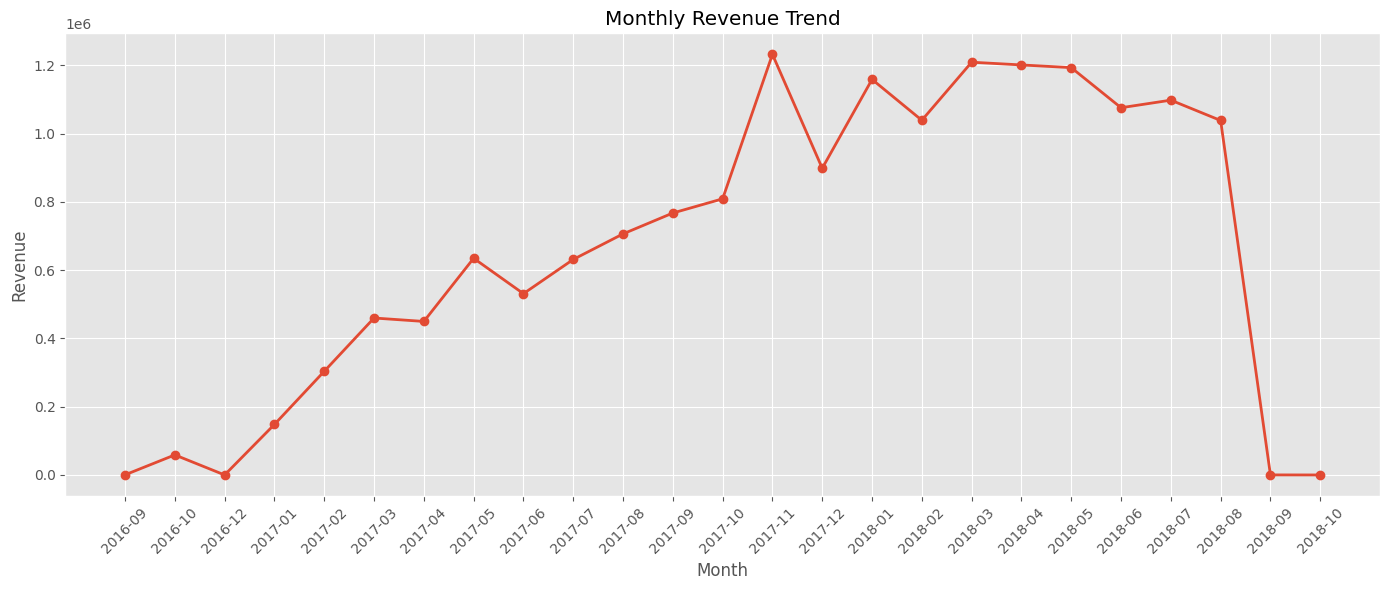

In [36]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_revenue["order_purchase_timestamp"],
    monthly_revenue["total_order_value"],
    marker="o",
    linewidth=2
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

# Business Insights

## Observation
- Revenue generally increased over the study period.
- Some months show noticeable peaks.
- A few months experienced slower growth.

## Root Cause
- Seasonal shopping patterns.
- Promotional campaigns.
- Increase in customer demand.
- Marketplace expansion.

## Recommendation
- Increase inventory before high-demand months.
- Launch marketing campaigns during slower months.
- Improve forecasting using historical trends.

## Business Impact
- Better inventory planning.
- Higher customer satisfaction.
- Increased revenue.
- Reduced stock shortages.

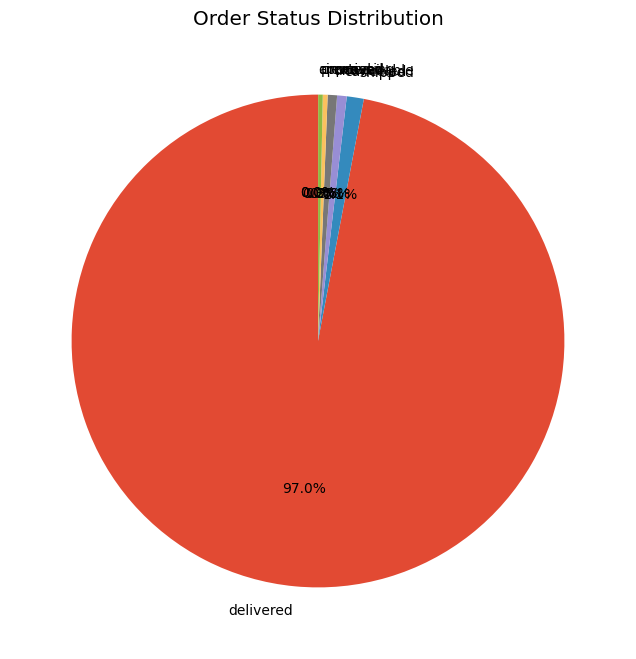

In [37]:
status = (
    orders["order_status"]
    .value_counts()
)

plt.figure(figsize=(8,8))

plt.pie(
    status,
    labels=status.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Order Status Distribution")

plt.show()

# Business Insights

### Observation
- Most orders were successfully delivered.

### Root Cause
- The marketplace has an efficient fulfillment process, though a small percentage of orders are cancelled or unavailable.

### Recommendation
- Analyze cancellation reasons and improve inventory synchronization.

### Business Impact
- Reducing cancelled orders increases revenue and improves customer satisfaction.

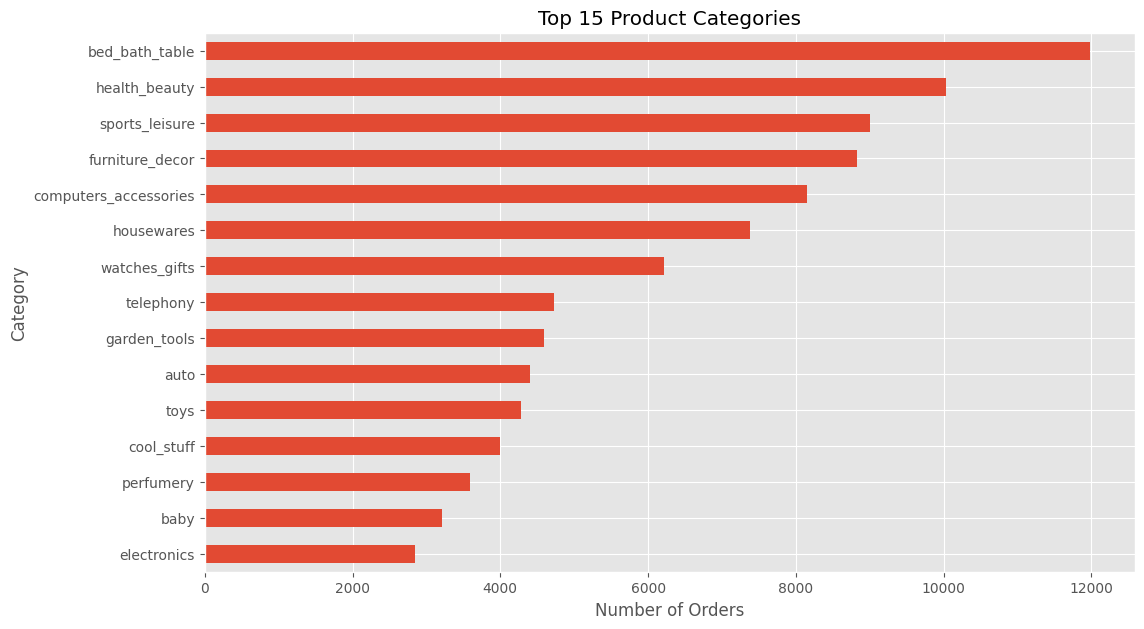

In [38]:
top_categories = (
    master_df["product_category_name_english"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,7))

top_categories.sort_values().plot(kind="barh")

plt.title("Top 15 Product Categories")

plt.xlabel("Number of Orders")

plt.ylabel("Category")

plt.show()

# Business Insights
### Observation

A small number of product categories account for a large share of total orders.

### Root Cause

These categories have consistently high customer demand.

### Recommendation

Maintain sufficient inventory and prioritize promotions for these categories.

### Business Impact

Improved sales, reduced stock-outs, and higher customer satisfaction.

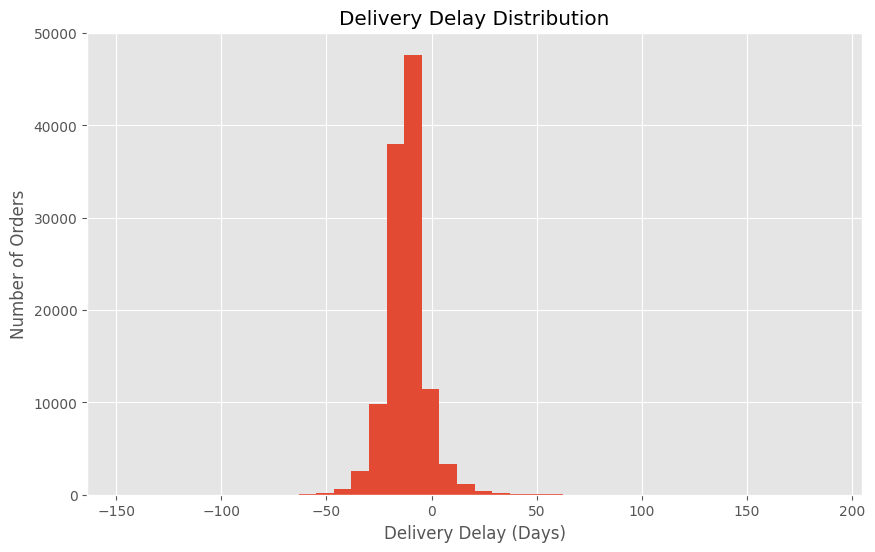

In [39]:
plt.figure(figsize=(10,6))

master_df["delivery_delay_days"].dropna().hist(bins=40)

plt.title("Delivery Delay Distribution")
plt.xlabel("Delivery Delay (Days)")
plt.ylabel("Number of Orders")

plt.show()

### Observation

Most orders are delivered on time or before the estimated date.
A small percentage experience significant delays.

### Root Cause

Long-distance shipping, seller delays, or courier issues.

### Recommendation

Monitor high-delay routes and improve logistics planning.

### Business Impact

Better customer satisfaction and lower negative reviews.

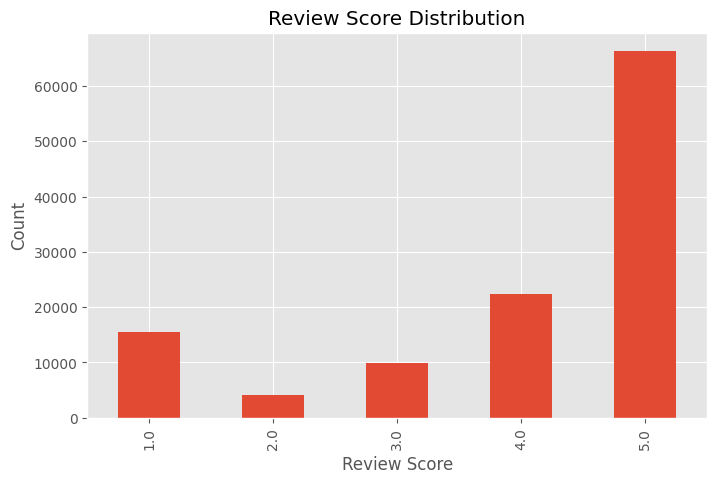

In [40]:
plt.figure(figsize=(8,5))

master_df["review_score"].value_counts().sort_index().plot(kind="bar")

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Count")

plt.show()

Most customers give 4–5 star ratings.
Very few customers leave 1-star reviews.
Overall customer satisfaction is good.

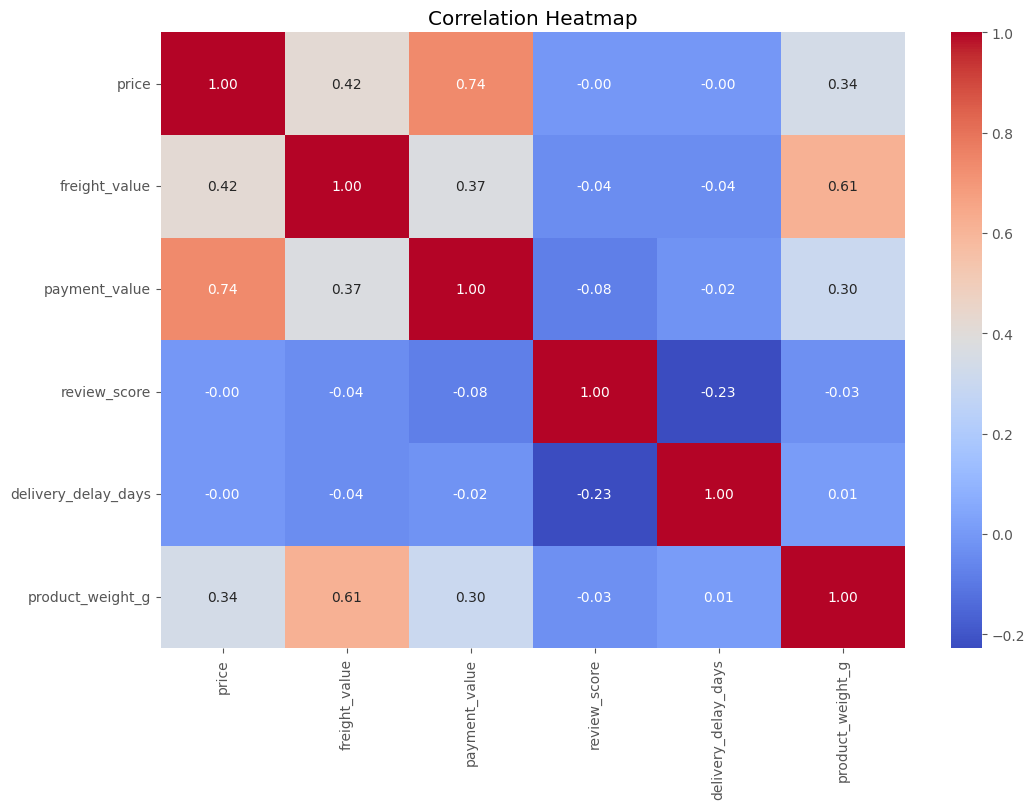

In [41]:
plt.figure(figsize=(12,8))

corr = master_df[
    [
        "price",
        "freight_value",
        "payment_value",
        "review_score",
        "delivery_delay_days",
        "product_weight_g"
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

A correlation heatmap helps identify relationships between numerical variables. It is useful for feature selection, detecting multicollinearity, and understanding how different business metrics influence each other before building machine learning models.

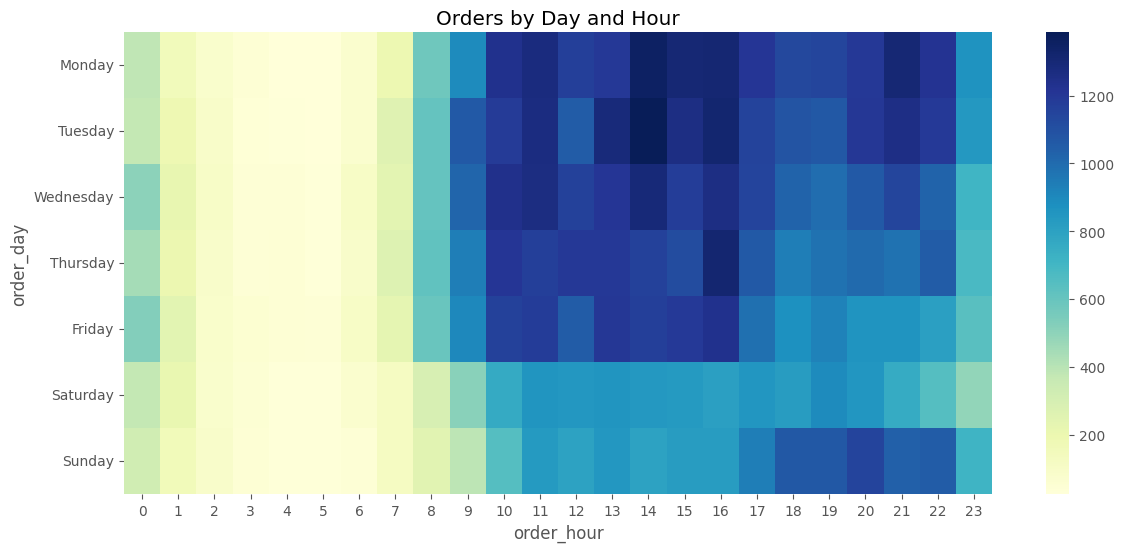

In [42]:
heatmap_data = master_df.pivot_table(
    index="order_day",
    columns="order_hour",
    values="order_id",
    aggfunc="count"
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Orders by Day and Hour")

plt.show()

This chart tells:

Which hour customers order the most.

Which weekday has maximum traffic.

Useful for:

Marketing timing
Flash sales,
Server planning

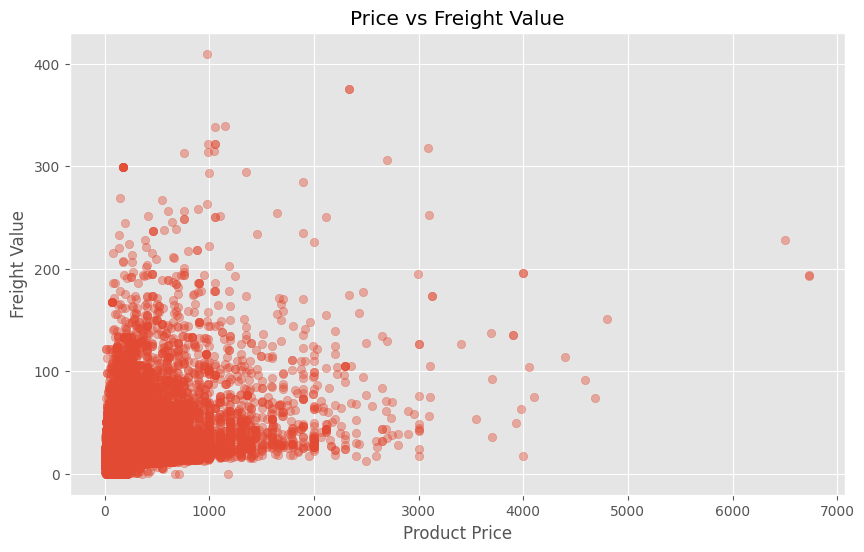

In [43]:
plt.figure(figsize=(10,6))

plt.scatter(
    master_df["price"],
    master_df["freight_value"],
    alpha=0.4
)

plt.xlabel("Product Price")
plt.ylabel("Freight Value")

plt.title("Price vs Freight Value")

plt.show()

Expensive products generally have higher freight costs.

Some low-priced products also have high freight due to size or location.

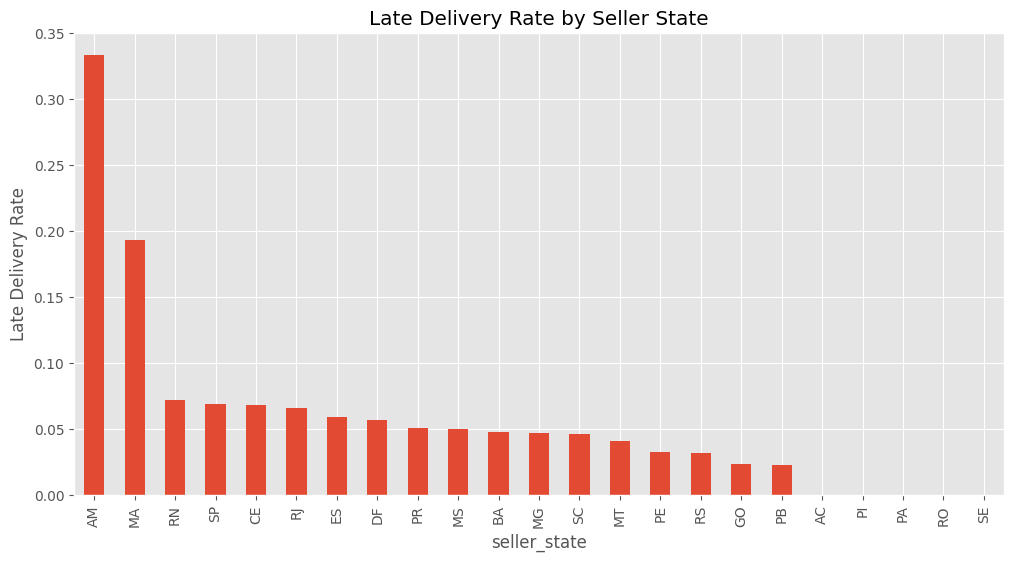

In [44]:
late_delivery = (
    master_df.groupby("seller_state")["is_late_delivery"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

late_delivery.plot(kind="bar")

plt.title("Late Delivery Rate by Seller State")

plt.ylabel("Late Delivery Rate")

plt.show()

Focus operational improvements on states with consistently high late delivery rates.

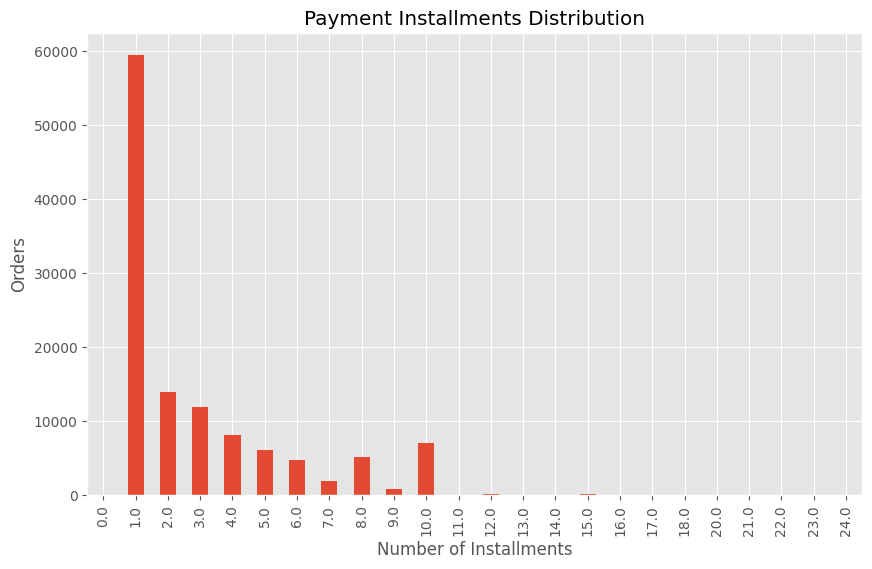

In [45]:
plt.figure(figsize=(10,6))

master_df["payment_installments"].value_counts().sort_index().plot(kind="bar")

plt.title("Payment Installments Distribution")

plt.xlabel("Number of Installments")

plt.ylabel("Orders")

plt.show()

This tells:

Whether customers prefer one-time payment or EMIs. 

Helps banks and finance teams design installment offers.

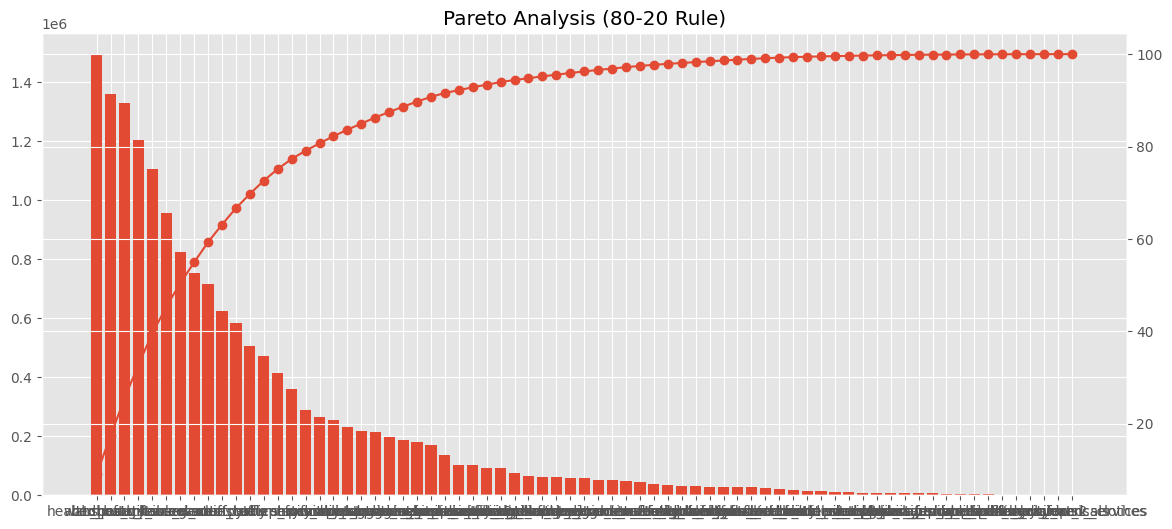

In [46]:
category_sales = (
    master_df.groupby("product_category_name_english")["total_order_value"]
    .sum()
    .sort_values(ascending=False)
)

pareto = category_sales.reset_index()
pareto.columns = ["Category", "Revenue"]

pareto["Cumulative Revenue"] = pareto["Revenue"].cumsum()
pareto["Cumulative %"] = (
    pareto["Cumulative Revenue"] /
    pareto["Revenue"].sum()
) * 100

fig, ax1 = plt.subplots(figsize=(14,6))

ax1.bar(pareto["Category"], pareto["Revenue"])

ax2 = ax1.twinx()

ax2.plot(
    pareto["Category"],
    pareto["Cumulative %"],
    marker="o"
)

plt.xticks(rotation=90)

plt.title("Pareto Analysis (80-20 Rule)")

plt.show()

Around 20% of product categories generate most of the revenue.
Focus marketing and inventory on these categories.

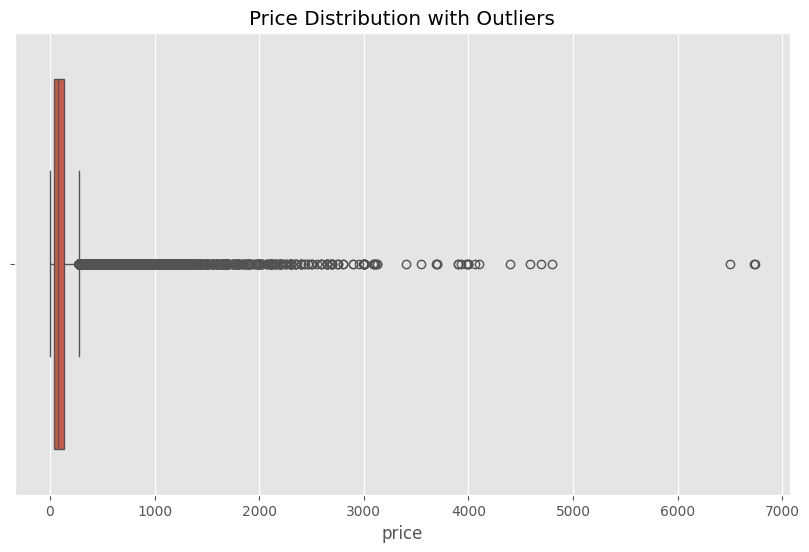

In [47]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=master_df["price"]
)

plt.title("Price Distribution with Outliers")

plt.show()

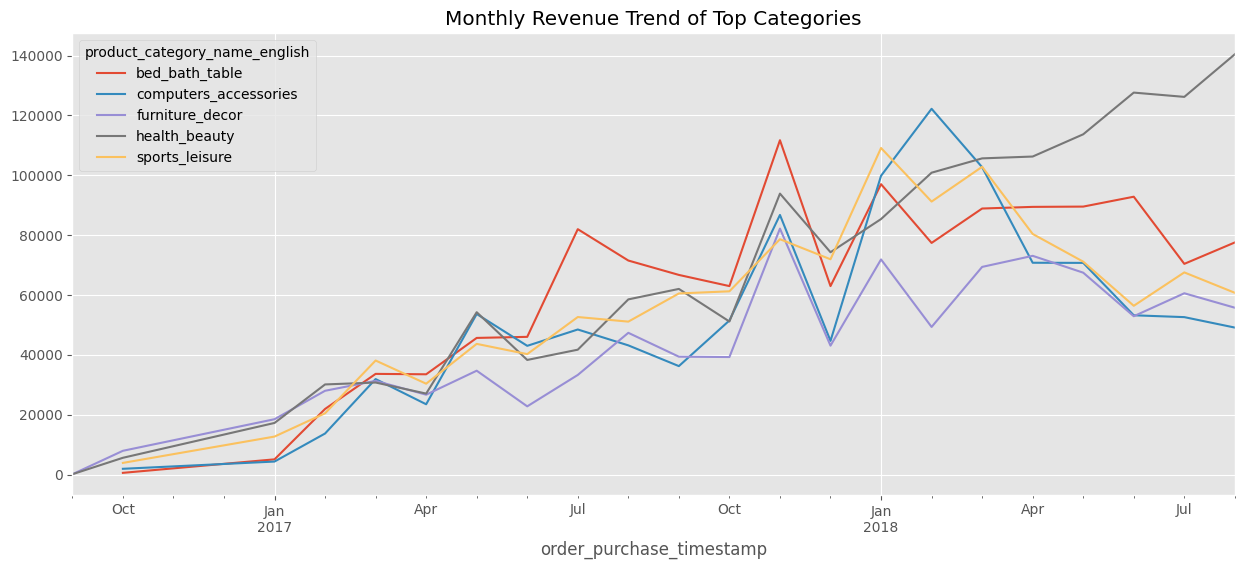

In [48]:
top5 = (
    master_df["product_category_name_english"]
    .value_counts()
    .head(5)
    .index
)

temp = master_df[
    master_df["product_category_name_english"].isin(top5)
]

pivot = temp.pivot_table(
    index=master_df["order_purchase_timestamp"].dt.to_period("M"),
    columns="product_category_name_english",
    values="total_order_value",
    aggfunc="sum"
)

pivot.plot(figsize=(15,6))

plt.title("Monthly Revenue Trend of Top Categories")

plt.show()

# Statistical Test 1 — Chi-Square Test
## Business Question

#### Is Review Score dependent on Late Delivery?

In [49]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(
    master_df["is_late_delivery"],
    master_df["review_sentiment"]
)

chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-Square:", chi2)
print("P-value:", p)

Chi-Square: 12791.589611800253
P-value: 0.0


In [50]:
if p < 0.05:
    print("Late delivery significantly affects customer reviews.")
else:
    print("No significant relationship found.")

Late delivery significantly affects customer reviews.


# Statistical Test 2 — Independent T-Test

In [51]:
master_df["customer_order_count"] = (
    master_df.groupby("customer_unique_id")["order_id"]
    .transform("nunique")
)

repeat = master_df[
    master_df["customer_order_count"] > 1
]["total_order_value"]

single = master_df[
    master_df["customer_order_count"] == 1
]["total_order_value"]

t_stat, p = stats.ttest_ind(
    repeat,
    single,
    equal_var=False
)

print("T Statistic:", t_stat)
print("P-value:", p)

T Statistic: nan
P-value: nan


In [52]:
if p < 0.05:
    print("Repeat customers spend significantly more.")
else:
    print("No significant spending difference.")

No significant spending difference.


# Statistical Test 3 — ANOVA

In [53]:
from scipy.stats import f_oneway

top_categories = (
    master_df["product_category_name_english"]
    .value_counts()
    .head(5)
    .index
)

groups = []

for category in top_categories:

    groups.append(

        master_df[
            master_df["product_category_name_english"] == category
        ]["delivery_delay_days"].dropna()

    )

F, p = f_oneway(*groups)

print("F Statistic:", F)
print("P-value:", p)

F Statistic: 9.624368684061261
P-value: 8.909632609743273e-08


In [54]:
if p < 0.05:
    print("Delivery time differs significantly across product categories.")
else:
    print("No significant difference found.")

Delivery time differs significantly across product categories.
